In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings('ignore')
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
PassengerId = test['PassengerId']
all_data = pd.concat([train, test], ignore_index=True)
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# 效果等同于上面的多条件筛选
# train.query('Sex=="male"')


In [4]:
all_data.columns
all_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0.0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0.0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0.0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1.0,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1.0,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [5]:
all_data.columns
all_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0.0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0.0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0.0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1.0,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1.0,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [6]:
all_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   str    
 4   Sex          1309 non-null   str    
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   str    
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    str    
 11  Embarked     1307 non-null   str    
dtypes: float64(3), int64(4), str(5)
memory usage: 122.8 KB


<Axes: xlabel='Sex', ylabel='Survived'>

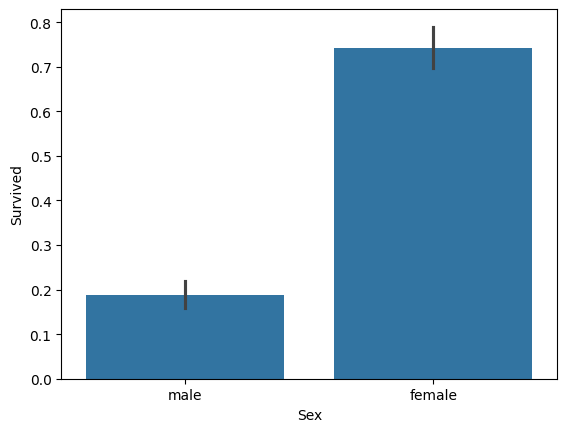

In [7]:
import matplotlib.pyplot as plt
all_data
df = all_data['Survived'].value_counts()
df
sns.barplot(x="Sex", y="Survived", data=all_data)
# 女性存活率更高

<Axes: xlabel='Pclass', ylabel='Survived'>

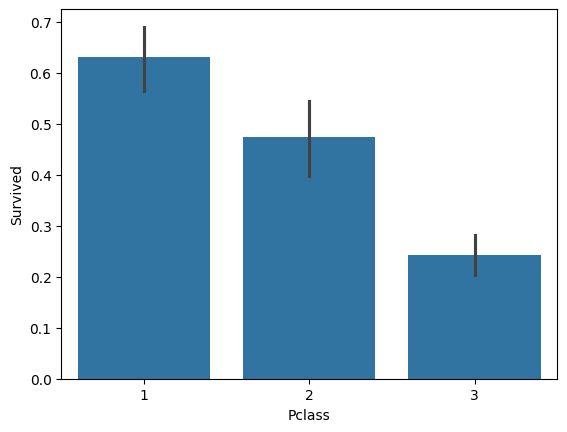

In [8]:
sns.barplot(x='Pclass', y='Survived', data=all_data)
# 舱位级别越高，存活率越高

<Axes: xlabel='SibSp', ylabel='Survived'>

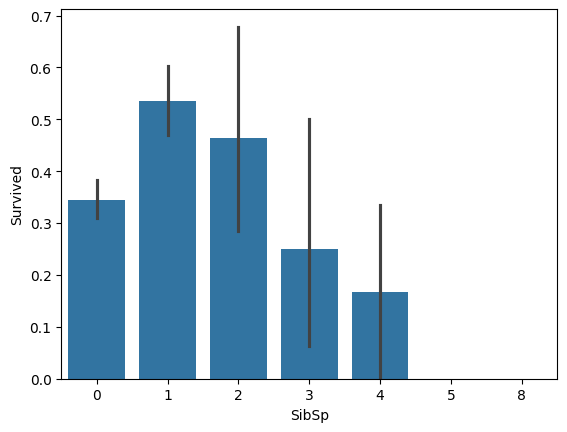

In [9]:
sns.barplot(x="SibSp", y="Survived", data=all_data)
# 兄弟姐妹数量

<Axes: xlabel='Parch', ylabel='Survived'>

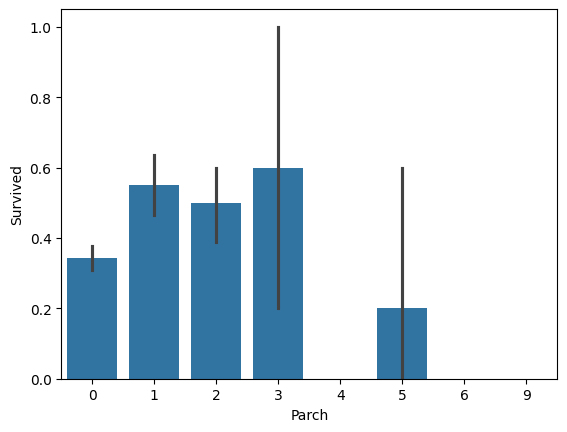

In [10]:
sns.barplot(x="Parch", y='Survived', data=all_data)
# 父母与小孩的个数

Text(672.6216036522636, 0.5, 'density')

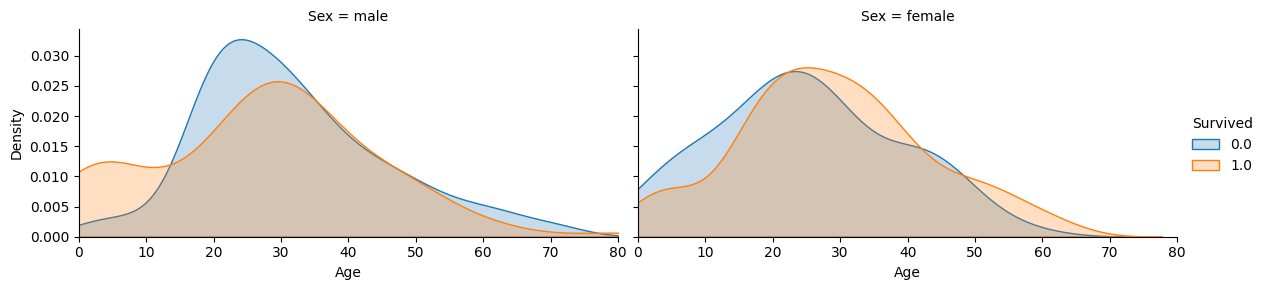

In [11]:
facet = sns.FacetGrid(data=all_data, hue='Survived', col='Sex', aspect=2)
facet.map(sns.kdeplot, 'Age', shade=True)
facet.set(xlim=(0, all_data['Age'].max()))
facet.add_legend()        # 添加图例（告诉你哪种颜色代表生还，哪种代表遇难）
plt.xlabel('Age')         # 设置 X 轴标签为“年龄”
plt.ylabel('density')     # 设置 Y 轴标签为“密度”

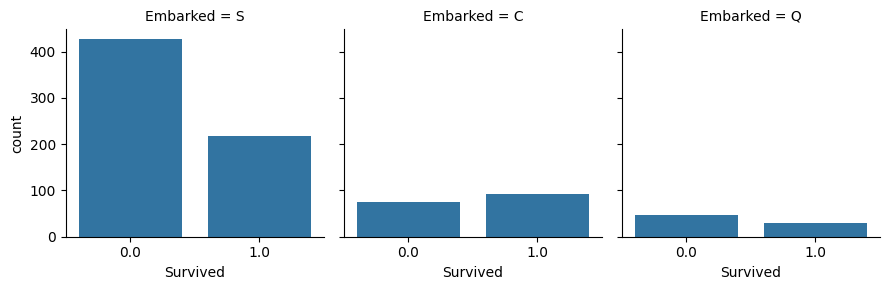

In [12]:
facet = sns.FacetGrid(data=all_data, col='Embarked')
facet.map(sns.countplot, 'Survived')
# sns.countplot(data=all_data, x='Embarked', hue='Survived')

In [13]:
all_data.groupby(['Embarked'])[['Pclass']].count()

,Pclass
Embarked,
C,270
Q,123
S,914


<Axes: xlabel='Title', ylabel='Survived'>

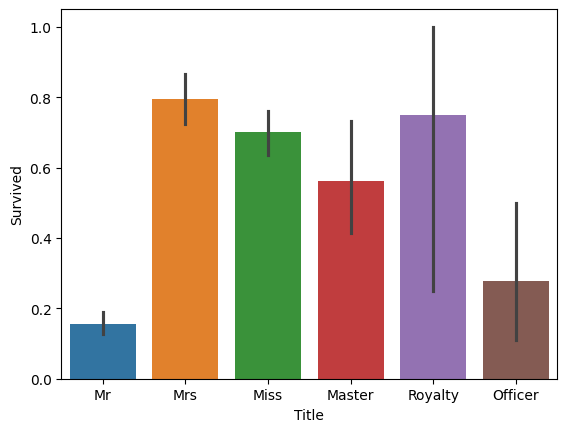

In [14]:
all_data['Title'] = all_data['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())
# all_data
Title_Dict = {}
Title_Dict.update(dict.fromkeys(['Capt', 'Col', 'Major', 'Dr', 'Rev'], 'Officer'))
Title_Dict.update(dict.fromkeys(['Don', 'Sir', 'the Countess', 'Dona', 'Lady'], 'Royalty'))
Title_Dict.update(dict.fromkeys(['Mme', 'Ms', 'Mrs'], 'Mrs'))
Title_Dict.update(dict.fromkeys(['Mlle', 'Miss'], 'Miss'))
Title_Dict.update(dict.fromkeys(['Mr'], 'Mr'))
Title_Dict.update(dict.fromkeys(['Master', 'Jonkheer'], 'Master'))

all_data['Title'] = all_data['Title'].map(Title_Dict)
sns.barplot(x="Title", y="Survived", data=all_data, hue="Title")

<Axes: xlabel='FamilySize', ylabel='Survived'>

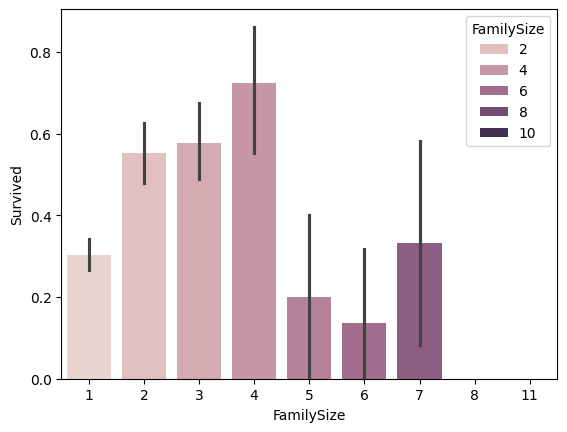

In [15]:
all_data['FamilySize'] = all_data['SibSp'] + all_data['Parch'] + 1
sns.barplot(data=all_data, x='FamilySize', y='Survived', hue='FamilySize')

<Axes: xlabel='FamilyLabel', ylabel='Survived'>

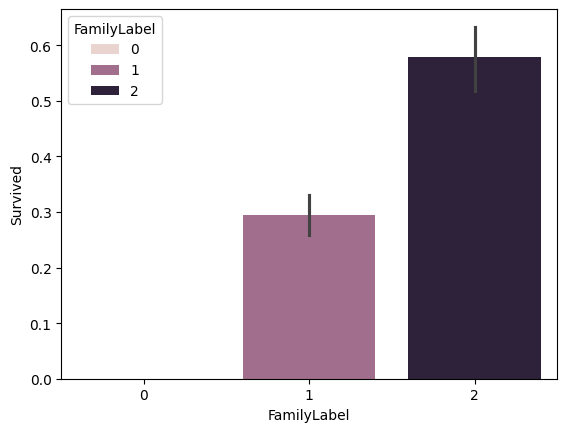

In [16]:
def Fam_label(s):
    if (s >= 2) and (s <= 4):
        return 2
    elif ((s > 4) and (s <= 7)) or (s == 1):
        return 1
    elif (s > 7):
        return 0
all_data['FamilyLabel'] = all_data['FamilySize'].apply(Fam_label)
sns.barplot(x="FamilyLabel", y="Survived", data=all_data, hue="FamilyLabel")

<Axes: xlabel='Deck', ylabel='Survived'>

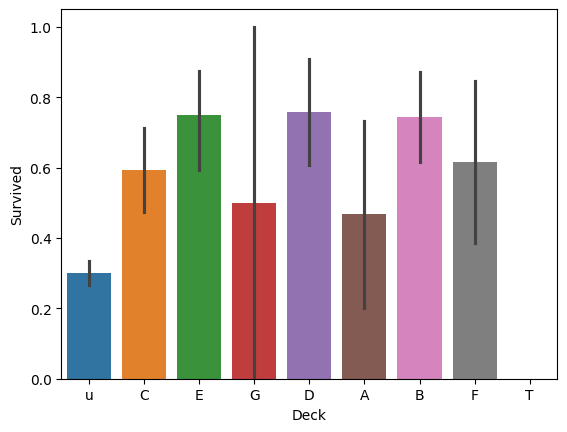

In [17]:
all_data['Cabin'] = all_data['Cabin'].fillna('unkonwn')
# res=all_data['Cabin'].str[0]
# all_data['Deck'] = res.apply(lambda x: x if x != 'u' else 'unknown')
all_data['Deck'] = all_data['Cabin'].str.get(0)
sns.barplot(x='Deck', y='Survived', data=all_data, hue='Deck')


<Axes: xlabel='TicketGroup', ylabel='Survived'>

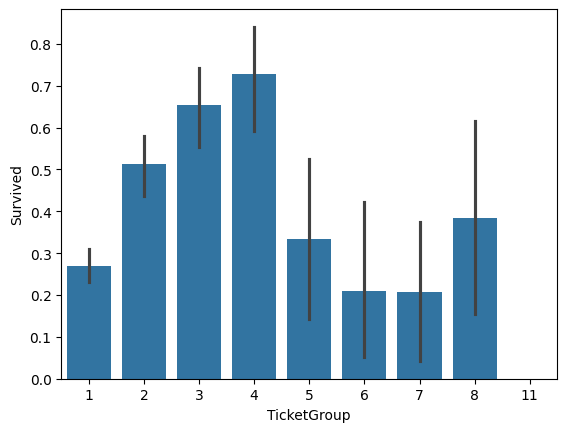

In [18]:
Ticket_Count = dict(all_data['Ticket'].value_counts())
all_data['TicketGroup'] = all_data['Ticket'].apply(lambda x: Ticket_Count[x])
sns.barplot(x='TicketGroup', y='Survived', data=all_data)

<Axes: xlabel='TicketGroup', ylabel='Survived'>

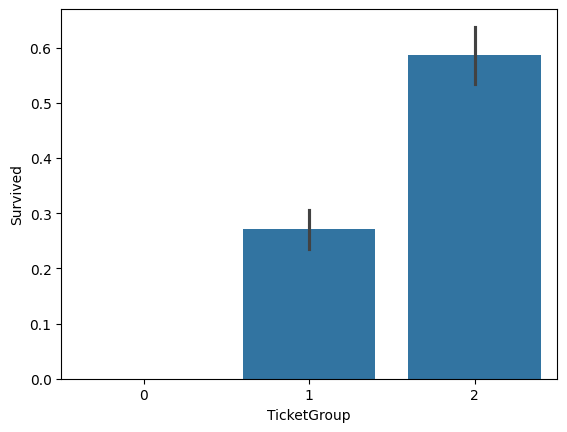

In [19]:
def ticket_lv(s):
    if s >= 2 and s <= 4:
        return 2
    elif (s > 4 and s <= 8) or s == 1:
        return 1
    elif s > 8:
        return 0
all_data['TicketGroup'] = all_data['TicketGroup'].apply(ticket_lv)
sns.barplot(x='TicketGroup', y='Survived', data=all_data)

In [20]:
from sklearn.ensemble import RandomForestRegressor
age_df = all_data[['Age', 'Pclass','Sex','Title']]

age_df=pd.get_dummies(age_df)

known_age = age_df[age_df.Age.notnull()].to_numpy()
unknown_age = age_df[age_df.Age.isnull()].to_numpy()
# known_age
# unknown_age

y = known_age[:, 0]
X = known_age[:, 1:]
rfr = RandomForestRegressor(random_state=0, n_estimators=100, n_jobs=-1)
rfr.fit(X, y)
predictedAges = rfr.predict(unknown_age[:,1:])
# predictedAges 
# all_data
all_data.loc[ (all_data.Age.isnull()), 'Age' ] = predictedAges 
# all_data[all_data['Embarked'].isnull()]
 

In [21]:
all_data[all_data['Embarked'].isnull()]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,FamilyLabel,Deck,TicketGroup
61,62,1.0,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,Miss,1,1,B,2
829,830,1.0,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,Mrs,1,1,B,2


In [22]:
all_data.groupby(by=['Pclass','Embarked']).Fare.median()

Pclass  Embarked
1       C           76.7292
        Q           90.0000
        S           52.0000
2       C           15.3146
        Q           12.3500
        S           15.3750
3       C            7.8958
        Q            7.7500
        S            8.0500
Name: Fare, dtype: float64

In [23]:
all_data['Embarked']=all_data['Embarked'].fillna('C')

In [24]:
train[train['Fare'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [25]:
fare = all_data[(all_data['Embarked'] == 'S') & (all_data['Pclass'] == 3)].Fare.median()
all_data['Fare'] = all_data['Fare'].fillna(fare)
all_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,FamilyLabel,Deck,TicketGroup
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,unkonwn,S,Mr,2,2,u,1
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C,Mrs,2,2,C,2
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,unkonwn,S,Miss,1,1,u,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S,Mrs,2,2,C,2
4,5,0.0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,unkonwn,S,Mr,1,1,u,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,28.226256,0,0,A.5. 3236,8.0500,unkonwn,S,Mr,1,1,u,1
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.000000,0,0,PC 17758,108.9000,C105,C,Royalty,1,1,C,2
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.500000,0,0,SOTON/O.Q. 3101262,7.2500,unkonwn,S,Mr,1,1,u,1
1307,1308,NaN,3,"Ware, Mr. Frederick",male,28.226256,0,0,359309,8.0500,unkonwn,S,Mr,1,1,u,1


In [26]:
all_data['Surname']=all_data['Name'].apply(lambda x:x.split(',')[0].strip())
Surname_Count = dict(all_data['Surname'].value_counts())

# Surname_Count


all_data['FamilyGroup'] = all_data['Surname'].apply(lambda x:Surname_Count[x])
# all_data['FamilyGroup'] 
Female_Child_Group=all_data[(all_data['FamilyGroup']>=2) & ((all_data['Age']<=12) | (all_data['Sex']=='female'))]
Male_Adult_Group=all_data.loc[(all_data['FamilyGroup']>=2) & (all_data['Age']>12) & (all_data['Sex']=='male')]

Female_Child_Group


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,FamilyLabel,Deck,TicketGroup,Surname,FamilyGroup
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C,Mrs,2,2,C,2,Cumings,2
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S,Mrs,2,2,C,2,Futrelle,2
7,8,0.0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,unkonwn,S,Master,5,1,u,1,Palsson,5
8,9,1.0,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000000,0,2,347742,11.1333,unkonwn,S,Mrs,3,2,u,2,Johnson,6
9,10,1.0,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000000,1,0,237736,30.0708,unkonwn,C,Mrs,2,2,u,2,Nasser,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1291,1292,NaN,1,"Bonnell, Miss. Caroline",female,30.000000,0,0,36928,164.8667,C7,S,Miss,1,1,C,2,Bonnell,2
1293,1294,NaN,1,"Gibson, Miss. Dorothy Winifred",female,22.000000,0,1,112378,59.4000,unkonwn,C,Miss,2,2,u,2,Gibson,2
1300,1301,NaN,3,"Peacock, Miss. Treasteall",female,3.000000,1,1,SOTON/O.Q. 3101315,13.7750,unkonwn,S,Miss,3,2,u,2,Peacock,3
1302,1303,NaN,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.000000,1,0,19928,90.0000,C78,Q,Mrs,2,2,C,2,Minahan,3


In [27]:
Female_Child=pd.DataFrame(Female_Child_Group.groupby('Surname')['Survived'].mean().value_counts())
Female_Child.columns=['GroupCount']
Female_Child

,GroupCount
Survived,
1.000000,115
0.000000,31
0.750000,2
0.333333,1
0.142857,1


Text(0.5, 0, 'AverageSurvived')

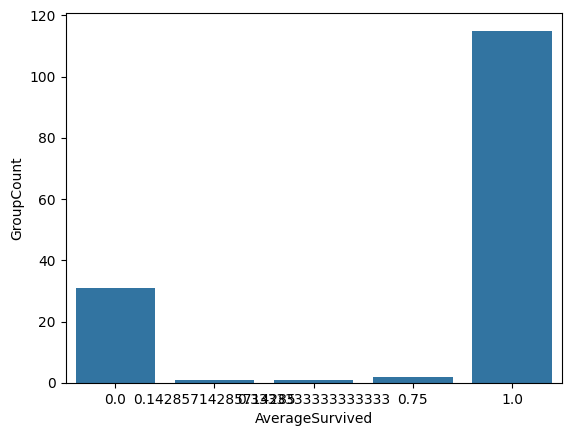

In [28]:
sns.barplot(x=Female_Child.index, y=Female_Child["GroupCount"]).set_xlabel('AverageSurvived')

In [29]:
Male_Adult=pd.DataFrame(Male_Adult_Group.groupby('Surname')['Survived'].mean().value_counts())
Male_Adult.columns=['GroupCount']
Male_Adult

,GroupCount
Survived,
0.000000,122
1.000000,20
0.500000,6
0.333333,2
0.250000,1


In [30]:
Female_Child_Group=Female_Child_Group.groupby('Surname')['Survived'].mean()
Female_Child_Group
Dead_List = set(Female_Child_Group[Female_Child_Group.apply(lambda x: x == 0)].index)
# Dead_List
print(Dead_List)
Male_Adult_List=Male_Adult_Group.groupby('Surname')['Survived'].mean()
Survived_List=set(Male_Adult_List[Male_Adult_List.apply(lambda x:x==1)].index)
print(Survived_List)

{'Jussila', 'Sage', 'Turpin', 'Attalah', 'Lefebre', 'Rosblom', 'Cacic', 'Canavan', 'Ilmakangas', 'Caram', 'Zabour', 'Ford', 'Olsson', 'Strom', 'Boulos', 'Rice', 'Johnston', 'Danbom', 'Lahtinen', 'Palsson', 'Barbara', 'Panula', 'Van Impe', 'Arnold-Franchi', 'Oreskovic', 'Robins', 'Goodwin', 'Vander Planke', 'Bourke', 'Lobb', 'Skoog'}
{'Taylor', 'Jussila', 'Jonsson', 'McCoy', 'Kimball', 'Chambers', 'Dick', 'Beane', 'Frolicher-Stehli', 'Bishop', 'Cardeza', 'Frauenthal', 'Bradley', 'Daly', 'Goldenberg', 'Harder', 'Greenfield', 'Duff Gordon', 'Nakid', 'Beckwith'}


In [31]:
# all_data
train=all_data.loc[all_data['Survived'].notnull()]
test=all_data.loc[all_data['Survived'].isnull()]

test.loc[(test['Surname'].apply(lambda x:x in Dead_List)),'Sex'] = 'male'
test.loc[(test['Surname'].apply(lambda x:x in Dead_List)),'Age'] = 60
test.loc[(test['Surname'].apply(lambda x:x in Dead_List)),'Title'] = 'Mr'
test.loc[(test['Surname'].apply(lambda x:x in Survived_List)),'Sex'] = 'female'
test.loc[(test['Surname'].apply(lambda x:x in Survived_List)),'Age'] = 5
test.loc[(test['Surname'].apply(lambda x:x in Survived_List)),'Title'] = 'Miss' 

In [32]:
all_data=pd.concat([train, test])
all_data=all_data[['Survived','Pclass','Sex','Age','Fare','Embarked','Title','FamilyLabel','Deck','TicketGroup']]
all_data=pd.get_dummies(all_data)
train=all_data[all_data['Survived'].notnull()]
test=all_data[all_data['Survived'].isnull()].drop('Survived',axis=1)
X = train.to_numpy()[:,1:]
y = train.values[:, 0].astype(int)



In [35]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest

from sklearn.model_selection import RandomizedSearchCV # 1. 换成随机搜索
import warnings
warnings.filterwarnings('ignore') # 2. 顺便屏蔽之前看到的红字警告

# 保持流水线不变
pipe = Pipeline([('select', SelectKBest(k=20)),
                ('classify', RandomForestClassifier(random_state=10, max_features='sqrt'))])

# 保持庞大的参数网格不变
param_test = {'classify__n_estimators': list(range(50, 500, 2)),
              'classify__max_depth': list(range(3, 60, 3))}

# 3. 核心变动在这里
gsearch = RandomizedSearchCV(
    estimator=pipe, 
    param_distributions=param_test, # 注意：参数名从 param_grid 变为了 param_distributions
    n_iter=100,      # 核心参数：总共随机抽 100 组来跑（之前我们要跑 4275 组）
    scoring='roc_auc', 
    cv=5,            # 适度调低 CV 增加速度
    n_jobs=-1, 
    random_state=42, # 随机抽样也要固定种子，方便复现
    verbose=2        # 开启进度条，让你看到它在动
)

gsearch.fit(X, y)
print(gsearch.best_params_, gsearch.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
{'classify__n_estimators': 144, 'classify__max_depth': 9} 0.875324897772867


In [ ]:
pd.DataFrame(gsearch.cv_results_)

In [51]:
import lightgbm as lgb

params = {
    'objective': 'binary',
    'device': 'gpu',      # 开启 GPU
    'gpu_platform_id': 0, # 通常 0 是你的 AMD 显卡
    'gpu_device_id': 0
}
# 使用 LightGBM 通常比写原生随机森林更能榨干 AMD 显卡的性能

In [53]:
from sklearn import model_selection, metrics
cv_score = model_selection.cross_val_score(pipeline, X, y, cv= 10)
print("CV Score : Mean - %.7g | Std - %.7g " % (np.mean(cv_score), np.std(cv_score)))

CV Score : Mean - 0.8406242 | Std - 0.04108182 


In [49]:
predictions = pipeline.predict(test)
submission = pd.DataFrame({"PassengerId": PassengerId, "Survived": predictions.astype(np.int32)})
submission.to_csv(r"S:\CodeDB\Solutions\Kaggle\titanic\submission2.csv", index=False)